In [12]:
import pandas as pd
# Load dataset
df = pd.read_csv("../data/NIFTY_50_COMPANIES.csv", usecols=['Date','Open','High','Low','Close','Volume','Ticker'])
print(df.head())


         Date      Close       High        Low       Open     Volume  \
0  1997-07-01  13.056603  13.345798  12.924502  13.281532  442137352   
1  1997-07-02  13.215482  13.456477  13.138720  13.226193  352633783   
2  1997-07-03  13.040537  13.263681  12.999478  13.147646  225940109   
3  1997-07-04  12.815608  13.111943  12.735276  13.076240  309913338   
4  1997-07-07  12.865592  13.040537  12.758483  12.781690  275138993   

        Ticker  
0  RELIANCE.NS  
1  RELIANCE.NS  
2  RELIANCE.NS  
3  RELIANCE.NS  
4  RELIANCE.NS  


In [13]:
print(df.columns)


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker'], dtype='object')


In [14]:
#Check info (important for cleaning)
# print(df.info)
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

# ⭐ Select ONLY TCS
df = df[df['Ticker'] == "TCS.NS"]

# Select only useful columns
df = df[['Date','Open','High','Low','Close','Volume']]

# Convert to numeric
for col in ['Open','High','Low','Close','Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

# Sort by date and set index
df = df.sort_values('Date')
df = df.set_index('Date')

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5772 entries, 2002-08-12 to 2025-11-11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5772 non-null   float64
 1   High    5772 non-null   float64
 2   Low     5772 non-null   float64
 3   Close   5772 non-null   float64
 4   Volume  5772 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 270.6 KB
None


,Open,High,Low,Close,Volume
Date,,,,,
2002-08-12,38.724998,40.000000,38.724998,39.700001,212976
2002-08-13,39.750000,40.387501,38.875000,39.162498,153576
2002-08-14,39.250000,39.250000,35.724998,36.462502,822776
2002-08-15,36.462502,36.462502,36.462502,36.462502,0
2002-08-16,36.275002,38.000000,35.750000,36.375000,811856


In [15]:
print(df.columns)


Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [16]:

# # Convert index to DateTime (important for time-series)
# df.index = pd.to_datetime(df.index, errors='coerce')

# # Remove rows where date conversion failed or values are missing
# df = df.dropna()

# # Sort by date just in case
# df = df.sort_index()

# # Show cleaned dataset
# df.head()
# df.info()
# Convert all columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop any rows that became NaN after conversion
df = df.dropna()

# Sort by date
df = df.sort_index()

# Confirm result
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5772 entries, 2002-08-12 to 2025-11-11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5772 non-null   float64
 1   High    5772 non-null   float64
 2   Low     5772 non-null   float64
 3   Close   5772 non-null   float64
 4   Volume  5772 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 270.6 KB
None
                 Open       High        Low      Close  Volume
Date                                                          
2002-08-12  38.724998  40.000000  38.724998  39.700001  212976
2002-08-13  39.750000  40.387501  38.875000  39.162498  153576
2002-08-14  39.250000  39.250000  35.724998  36.462502  822776
2002-08-15  36.462502  36.462502  36.462502  36.462502       0
2002-08-16  36.275002  38.000000  35.750000  36.375000  811856


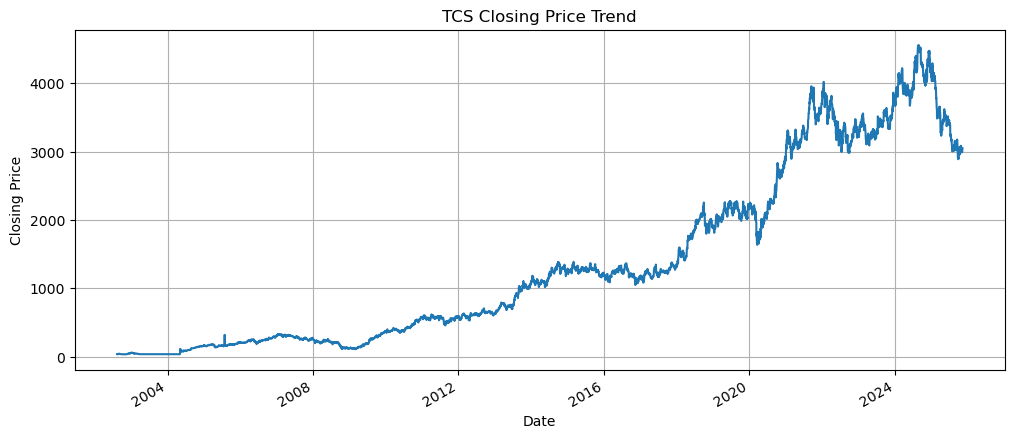

In [17]:
import matplotlib.pyplot as plt

df['Close'].plot(figsize=(12,5), title="TCS Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid()
plt.show()


In [18]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Select only Close prices
data = df[['Close']].values 

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Create sequences (60 days input → 1 day output)
X_train, y_train = [], []
for i in range(60, len(scaled_data)):
    X_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (5712, 60, 1)
y_train shape: (5712,)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)  # final prediction output
])

model.compile(optimizer='adam', loss='mean_squared_error')

print(" Training started... please wait ")
history = model.fit(X_train, y_train, epochs=15, batch_size=32)
model.save("../models/tcs_lstm_model.h5")
print(" Training Complete!")


 Training started... please wait 
Epoch 1/15


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0062
Epoch 2/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0015
Epoch 3/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0014
Epoch 4/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0013
Epoch 5/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0011    
Epoch 6/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0012
Epoch 7/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0010    
Epoch 8/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 9.5417e-04
Epoch 9/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 9.6529e-04
Epoch 10/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 8.9307e-04
Epoch 11/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 9.1360e-04
Epoch 12/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 8.9653e-04
Epoch 13/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 8.3141e-04
Epoch 14/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 7.2131e-04
Epoch 15/15
179/17

 Training Complete!


In [22]:
# Prepare last 60 days for prediction
last_60 = scaled_data[-60:].reshape(1, 60, 1)

# Predict next value
pred_scaled = model.predict(last_60)
predicted_price = scaler.inverse_transform(pred_scaled)[0][0]

# Get last actual price
current_price = df['Close'].iloc[-1]

print(" Predicted Next Day TCS Price:", round(predicted_price, 2))
print("Current Last Price:", current_price)

if predicted_price > current_price:
    print(" Prediction: Price may go UP (Bullish) ")
else:
    print("Prediction: Price may go DOWN (Bearish)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
 Predicted Next Day TCS Price: 2975.66
Current Last Price: 3047.0
Prediction: Price may go DOWN (Bearish)


179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step   


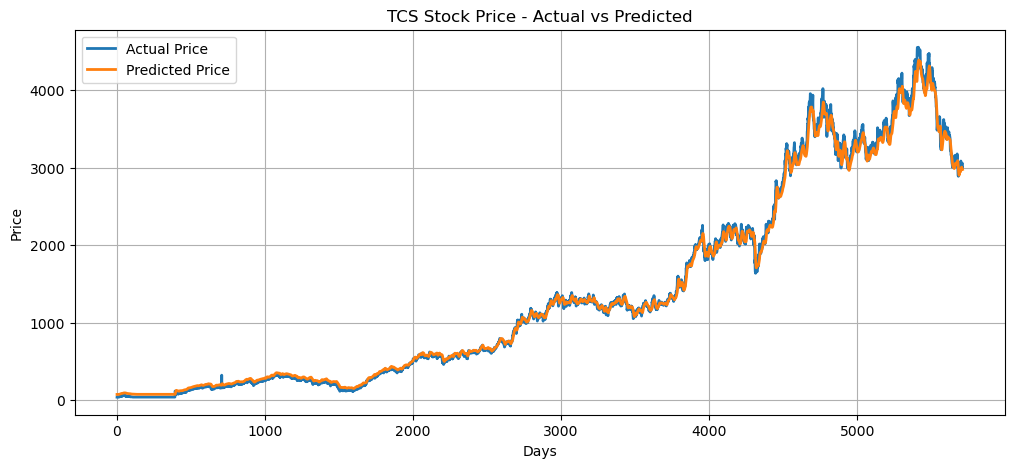

In [23]:
import matplotlib.pyplot as plt

# Predict on the entire dataset (for visualization)
predictions = model.predict(X_train)
predictions = scaler.inverse_transform(predictions)  # convert back to original price range

# Actual Close Prices
actual_prices = df['Close'].iloc[60:].values  # starting after first 60 days

# Plotting
plt.figure(figsize=(12,5))
plt.plot(actual_prices, label="Actual Price", linewidth=2)
plt.plot(predictions, label="Predicted Price", linewidth=2)
plt.title("TCS Stock Price - Actual vs Predicted")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


In [24]:
import numpy as np
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(actual_prices, predictions)
print("MSE:", mse)
print("RMSE:", np.sqrt(mse))


MSE: 3760.960341561871
RMSE: 61.326669089082856


In [27]:
!streamlit run app.py


Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
